# Notebook 05 — Base de Sentimentos com Lags para Modelagem

**Objetivo**: construir uma base mensal de sentimento/tom dos documentos do Banco Central e gerar variáveis defasadas até 6 meses para uso no Notebook 06.

A escolha do melhor modelo de sentimento **não será feita neste notebook**. Aqui são geradas as variáveis e realizadas análises diagnósticas de correlação. A decisão final sobre quais variáveis usar deve ocorrer no **Notebook 06**, com base no desempenho preditivo dos modelos, especialmente pelo **RMSE** — raiz do erro quadrático médio.

**Entradas**:
- `base_modelagem_inadimplencia.csv`: série mensal de inadimplência;
- `base_sentimentos.csv`: base consolidada de sentimentos do Notebook 04.

**Saída principal**:
- `base_sentimento_lags_todos_relatorios.csv`: base única com todos os relatórios, todos os modelos de sentimento e lags de 1 a 6 meses. As colunas recebem prefixo do tipo de relatório, por exemplo: `copom_score_mistral_L1` e `estatisticas_score_mistral_L1`.

In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 1. Carregamento das bases

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Série de Inadimplência (Notebook 02) 
df_inad = pd.read_csv("base_modelagem_inadimplencia.csv")



# ── Scores de Sentimento (Notebook 04) ──────────────────────────────────────
URL_SENT = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_sentimentos.csv"
try:
    df_sent = pd.read_csv("base_sentimentos.csv")
    print("base_sentimentos.csv carregado do disco.")
except FileNotFoundError:
    df_sent = pd.read_csv(URL_SENT)
    print("base_sentimentos.csv carregado do GitHub.")

df_sent.columns = [c.strip().lower() for c in df_sent.columns]
df_sent["data"] = pd.to_datetime(df_sent["data"], errors="coerce")

# Identificar colunas de score
score_cols_raw = [c for c in df_sent.columns if c.startswith("score_")]
print(f"Scores disponíveis: {score_cols_raw}")


base_sentimentos.csv carregado do disco.
Scores disponíveis: ['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']


In [3]:
df_inad

,Unnamed: 0,data,data_alvo,inad_total_tplus3,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6
0,6,2019-07-01,2019-10-01,3.03,3.06,2.95,3.05,3.02,2.99,2.91,2.95
1,7,2019-08-01,2019-11-01,3.00,3.04,3.06,2.95,3.05,3.02,2.99,2.91
2,8,2019-09-01,2019-12-01,2.94,3.06,3.04,3.06,2.95,3.05,3.02,2.99
3,9,2019-10-01,2020-01-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,3.02
4,10,2019-11-01,2020-02-01,3.04,3.00,3.03,3.06,3.04,3.06,2.95,3.05
...,...,...,...,...,...,...,...,...,...,...,...
70,76,2025-05-01,2025-08-01,3.95,3.54,3.50,3.28,3.26,3.19,2.95,3.14
71,77,2025-06-01,2025-09-01,3.91,3.57,3.54,3.50,3.28,3.26,3.19,2.95
72,78,2025-07-01,2025-10-01,4.00,3.77,3.57,3.54,3.50,3.28,3.26,3.19
73,79,2025-08-01,2025-11-01,4.05,3.95,3.77,3.57,3.54,3.50,3.28,3.26


In [4]:
df_sent

,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.7783,0.000000,-0.071429,-0.248734,0.50
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.6808,0.000000,-0.062500,-0.336417,0.50
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.9274,0.062500,-0.125000,-0.388865,0.65
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.7783,0.000000,-0.187500,-0.407422,0.75
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.8402,0.000000,0.062500,-0.227865,0.75
...,...,...,...,...,...,...,...,...,...
129,2025-08-01,estatisticas,202508_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9894,0.000000,-0.916667,-0.018209,-0.10
130,2025-09-01,estatisticas,202509_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9776,0.050000,-1.000000,0.007749,-0.60
131,2025-10-01,estatisticas,202510_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9920,-0.400000,-1.000000,-0.007200,0.65
132,2025-11-01,estatisticas,202511_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9898,-0.266667,-1.000000,0.292047,-0.30


## 2. Agregação mensal com grade completa e interpolação

A série de inadimplência é mensal. Como as **Atas do Copom** não ocorrem exatamente todos os meses — em geral, seguem o calendário de reuniões do Copom, que pode ocorrer em intervalos próximos de 45 dias — é necessário transformar o sentimento das atas em uma série mensal contínua.

A regra aplicada neste notebook é:

1. agregar os scores de sentimento por mês e por tipo de relatório;
2. criar uma grade mensal completa de `2019-01-01` até `2025-12-01`;
3. garantir que, para todos os meses, exista valor de sentimento para as **Atas do Copom**, usando interpolação linear para preencher lacunas internas;
4. aplicar `bfill/ffill` — preenchimento com o valor seguinte/anterior — apenas nas bordas da série, quando necessário;
5. manter colunas de rastreabilidade para identificar quais meses eram observados originalmente e quais foram preenchidos.

Os Relatórios de Estatísticas também são mantidos na base consolidada, mas o ponto metodológico mais importante aqui é a mensalização das Atas do Copom para compatibilização com a série mensal de inadimplência.

In [5]:
df_sent_completo = df_sent.copy()

# ── Padronização da identificação do tipo de relatório ──────────────────────
if "tipo_relatorio" not in df_sent_completo.columns:
    if "tipo" in df_sent_completo.columns:
        df_sent_completo["tipo_relatorio"] = df_sent_completo["tipo"]
    else:
        raise ValueError(
            "A coluna 'tipo_relatorio' não foi encontrada na base_sentimentos.csv. "
            "Verifique se o Notebook 04 exportou a base consolidada corretamente."
        )

df_sent_completo["tipo_relatorio"] = (
    df_sent_completo["tipo_relatorio"]
    .astype(str)
    .str.lower()
    .str.strip()
)

TIPOS_VALIDOS = ["copom", "estatisticas"]
df_sent_completo = df_sent_completo[
    df_sent_completo["tipo_relatorio"].isin(TIPOS_VALIDOS)
].copy()

# ── Padronização da data e dos scores ───────────────────────────────────────
df_sent_completo["data"] = pd.to_datetime(df_sent_completo["data"], errors="coerce")
df_sent_completo = df_sent_completo.dropna(subset=["data"])

# Garantir que os scores sejam numéricos
for col in score_cols_raw:
    df_sent_completo[col] = pd.to_numeric(df_sent_completo[col], errors="coerce")

score_cols = [c for c in score_cols_raw if df_sent_completo[c].notna().any()]

print("Scores válidos para análise:")
print(score_cols)

print("\nDistribuição da base completa por tipo de relatório:")
display(
    df_sent_completo["tipo_relatorio"]
    .value_counts()
    .rename_axis("tipo_relatorio")
    .reset_index(name="qtd_registros")
)

# ── Grade mensal completa ───────────────────────────────────────────────────
PERIODO_INICIO = "2019-01-01"
PERIODO_FIM = "2025-12-01"

grade_mensal = pd.date_range(
    start=PERIODO_INICIO,
    end=PERIODO_FIM,
    freq="MS"
)

print(f"\nGrade mensal esperada: {len(grade_mensal)} meses")
print(f"Período: {grade_mensal.min().date()} a {grade_mensal.max().date()}")


def agregar_mensal_com_interpolacao(df_base, tipo_relatorio, score_cols, grade_mensal):
    """
    Agrega os scores por mês para um tipo de relatório e garante uma série mensal completa.

    Para as Atas do Copom, essa etapa é essencial porque as atas não são mensais.
    A interpolação linear preenche lacunas internas entre observações conhecidas.
    """
    df_tipo = df_base[df_base["tipo_relatorio"] == tipo_relatorio].copy()

    if df_tipo.empty:
        raise ValueError(f"Não há registros para tipo_relatorio = '{tipo_relatorio}'.")

    df_tipo["mes"] = df_tipo["data"].dt.to_period("M").dt.to_timestamp()

    # Agregação mensal: se houver mais de um documento no mesmo mês, usa a média.
    df_obs = (
        df_tipo.groupby("mes")[score_cols]
        .mean()
        .sort_index()
    )

    meses_observados = set(df_obs.index)

    # Grade mensal completa
    df_mensal = df_obs.reindex(grade_mensal)
    df_mensal.index.name = "data"
    df_mensal = df_mensal.reset_index()

    df_mensal["tipo_relatorio"] = tipo_relatorio
    df_mensal["registro_original"] = df_mensal["data"].isin(meses_observados)
    df_mensal["mes_ausente_originalmente"] = ~df_mensal["registro_original"]

    # Preenchimento das lacunas internas
    scores_interpolados = df_mensal[score_cols].interpolate(
        method="linear",
        limit_area="inside"
    )

    # Preenchimento de bordas, quando necessário
    scores_preenchidos = scores_interpolados.bfill().ffill()

    df_mensal[score_cols] = scores_preenchidos

    # Rastreabilidade do método de preenchimento
    df_mensal["metodo_preenchimento"] = "observado"

    mask_interpolado = (
        df_mensal["mes_ausente_originalmente"]
        & scores_interpolados.notna().any(axis=1)
    )
    df_mensal.loc[mask_interpolado, "metodo_preenchimento"] = "interpolacao_linear"

    mask_borda = (
        df_mensal["mes_ausente_originalmente"]
        & ~mask_interpolado
    )
    df_mensal.loc[mask_borda, "metodo_preenchimento"] = "bfill_ffill_borda"

    return df_mensal


# Gerar base mensal completa para cada tipo de relatório
dfs_mensais = []
for tipo in TIPOS_VALIDOS:
    df_tipo_mensal = agregar_mensal_com_interpolacao(
        df_base=df_sent_completo,
        tipo_relatorio=tipo,
        score_cols=score_cols,
        grade_mensal=grade_mensal
    )
    dfs_mensais.append(df_tipo_mensal)

df_sent_mensal = pd.concat(dfs_mensais, ignore_index=True)

# Verificação da cobertura mensal
resumo_cobertura = (
    df_sent_mensal
    .groupby("tipo_relatorio")
    .agg(
        meses_total=("data", "nunique"),
        registros_originais=("registro_original", "sum"),
        meses_preenchidos=("mes_ausente_originalmente", "sum")
    )
    .reset_index()
)

print("\n=== Cobertura mensal após interpolação ===")
display(resumo_cobertura)

print("\nMétodo de preenchimento por tipo de relatório:")
display(
    df_sent_mensal
    .groupby(["tipo_relatorio", "metodo_preenchimento"])
    .size()
    .reset_index(name="qtd_meses")
)

# Checagem específica solicitada pelo professor: Copom deve ter todos os meses.
qtd_meses_copom = df_sent_mensal.query("tipo_relatorio == 'copom'")["data"].nunique()
assert qtd_meses_copom == len(grade_mensal), (
    f"Copom deveria ter {len(grade_mensal)} meses, mas tem {qtd_meses_copom}."
)

print(f"\n✅ Série mensal do Copom completa: {qtd_meses_copom} meses.")
display(df_sent_mensal.head())

Scores válidos para análise:
['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']

Distribuição da base completa por tipo de relatório:


,tipo_relatorio,qtd_registros
0,estatisticas,81
1,copom,53



Grade mensal esperada: 84 meses
Período: 2019-01-01 a 2025-12-01

=== Cobertura mensal após interpolação ===


,tipo_relatorio,meses_total,registros_originais,meses_preenchidos
0,copom,84,53,31
1,estatisticas,84,81,3



Método de preenchimento por tipo de relatório:


,tipo_relatorio,metodo_preenchimento,qtd_meses
0,copom,bfill_ffill_borda,1
1,copom,interpolacao_linear,30
2,copom,observado,53
3,estatisticas,interpolacao_linear,3
4,estatisticas,observado,81



✅ Série mensal do Copom completa: 84 meses.


,data,score_nltk,score_textblob,score_bert,score_finbert,score_mistral,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento
0,2019-01-01,-0.7783,0.00000,-0.071429,-0.248734,0.500,copom,False,True,bfill_ffill_borda
1,2019-02-01,-0.7783,0.00000,-0.071429,-0.248734,0.500,copom,True,False,observado
2,2019-03-01,-0.6808,0.00000,-0.062500,-0.336417,0.500,copom,True,False,observado
3,2019-04-01,-0.8041,0.03125,-0.093750,-0.362641,0.575,copom,False,True,interpolacao_linear
4,2019-05-01,-0.9274,0.06250,-0.125000,-0.388865,0.650,copom,True,False,observado


## 3. Modelo 6 — Média dos modelos de sentimento

In [6]:
# Sentimento médio dos modelos válidos
df_sent_mensal["score_media"] = df_sent_mensal[score_cols].mean(axis=1)
score_cols_todos = score_cols + ["score_media"]

print("Score médio (primeiros 5):")
df_sent_mensal



Score médio (primeiros 5):


,data,score_nltk,score_textblob,score_bert,score_finbert,score_mistral,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento,score_media
0,2019-01-01,-0.7783,0.000000,-0.071429,-0.248734,0.500,copom,False,True,bfill_ffill_borda,-0.119692
1,2019-02-01,-0.7783,0.000000,-0.071429,-0.248734,0.500,copom,True,False,observado,-0.119692
2,2019-03-01,-0.6808,0.000000,-0.062500,-0.336417,0.500,copom,True,False,observado,-0.115943
3,2019-04-01,-0.8041,0.031250,-0.093750,-0.362641,0.575,copom,False,True,interpolacao_linear,-0.130848
4,2019-05-01,-0.9274,0.062500,-0.125000,-0.388865,0.650,copom,True,False,observado,-0.145753
...,...,...,...,...,...,...,...,...,...,...,...
163,2025-08-01,-0.9894,0.000000,-0.916667,-0.018209,-0.100,estatisticas,True,False,observado,-0.404855
164,2025-09-01,-0.9776,0.050000,-1.000000,0.007749,-0.600,estatisticas,True,False,observado,-0.503970
165,2025-10-01,-0.9920,-0.400000,-1.000000,-0.007200,0.650,estatisticas,True,False,observado,-0.349840
166,2025-11-01,-0.9898,-0.266667,-1.000000,0.292047,-0.300,estatisticas,True,False,observado,-0.452884


## 4. Preparação das bases para geração dos lags e merge

Nesta etapa, a base de inadimplência é apenas preparada para o merge, mas **ainda não é unida** à base de sentimento.

A lógica adotada é:

1. a base mensal de sentimento começa em `2019-01-01`;
2. os lags dos scores de sentimento são calculados sobre essa série mensal completa;
3. depois dos lags, a base de sentimento é limpa com `dropna()`;
4. somente depois dessa limpeza é feito o merge com a base de inadimplência.

Esse fluxo evita perder a informação de janeiro a junho de 2019 no cálculo dos lags. Por exemplo, o lag 6 de julho de 2019 usa o sentimento de janeiro de 2019.



In [7]:
# Cópias para evitar alterar os dataframes originais diretamente
# dataframe = estrutura tabular do pandas, parecida com uma planilha
df_inad_merge = df_inad.copy()
df_sent_lag_base = df_sent_mensal.copy()

# ── Parâmetro principal da etapa ────────────────────────────────────────────
# Os lags de sentimento devem ser calculados a partir de 2019-01-01,
# antes do merge com a base de inadimplência.
DATA_INICIO_LAGS_SENTIMENTO = pd.Timestamp("2019-01-01")

# ── Preparação da base de inadimplência ─────────────────────────────────────
# A base de inadimplência já vem do Notebook 02 com os lags da própria série,
# como inad_total_L1, inad_total_L2, etc. Esses lags NÃO serão recriados aqui.
df_inad_merge.columns = [c.strip().lower() for c in df_inad_merge.columns]
df_inad_merge = df_inad_merge.drop(columns=["unnamed: 0", "Unnamed: 0"], errors="ignore")

if "data" not in df_inad_merge.columns:
    raise ValueError("A base de inadimplência precisa ter uma coluna chamada 'data'.")

df_inad_merge["data"] = pd.to_datetime(df_inad_merge["data"], errors="coerce")
df_inad_merge["mes"] = df_inad_merge["data"].dt.to_period("M").dt.to_timestamp()

df_inad_merge = (
    df_inad_merge
    .dropna(subset=["mes"])
    .drop_duplicates(subset=["mes"])
    .sort_values("mes")
    .reset_index(drop=True)
)

# ── Preparação da base mensal de sentimento ─────────────────────────────────
df_sent_lag_base["data"] = pd.to_datetime(df_sent_lag_base["data"], errors="coerce")
df_sent_lag_base["mes"] = df_sent_lag_base["data"].dt.to_period("M").dt.to_timestamp()

df_sent_lag_base = (
    df_sent_lag_base
    .dropna(subset=["mes", "tipo_relatorio"])
    .query("mes >= @DATA_INICIO_LAGS_SENTIMENTO")
    .sort_values(["tipo_relatorio", "mes"])
    .reset_index(drop=True)
)

# Conferir se a base mensal de sentimento tem apenas uma linha por mês e tipo de relatório.
# Isso é importante porque os lags precisam ser calculados em uma série temporal mensal única.
duplicados_sent = df_sent_lag_base[
    df_sent_lag_base.duplicated(subset=["mes", "tipo_relatorio"], keep=False)
]

if not duplicados_sent.empty:
    print("Atenção: foram encontrados meses duplicados na base mensal de sentimento.")
    display(duplicados_sent[["data", "mes", "tipo_relatorio"] + score_cols_todos].head(10))
else:
    print("✅ Base de sentimento mensal sem duplicidade por mês e tipo de relatório.")

print("=== Bases preparadas ===")
print(f"Inadimplência: {len(df_inad_merge)} linhas | período: {df_inad_merge['mes'].min().date()} a {df_inad_merge['mes'].max().date()}")
print(f"Sentimento mensal para lags: {len(df_sent_lag_base)} linhas | período: {df_sent_lag_base['mes'].min().date()} a {df_sent_lag_base['mes'].max().date()}")

print("\nCobertura da base de sentimento por tipo de relatório:")
display(
    df_sent_lag_base
    .groupby("tipo_relatorio")
    .agg(
        inicio=("mes", "min"),
        fim=("mes", "max"),
        qtd_meses=("mes", "nunique")
    )
    .reset_index()
)



✅ Base de sentimento mensal sem duplicidade por mês e tipo de relatório.
=== Bases preparadas ===
Inadimplência: 75 linhas | período: 2019-07-01 a 2025-09-01
Sentimento mensal para lags: 168 linhas | período: 2019-01-01 a 2025-12-01

Cobertura da base de sentimento por tipo de relatório:


,tipo_relatorio,inicio,fim,qtd_meses
0,copom,2019-01-01,2025-12-01,84
1,estatisticas,2019-01-01,2025-12-01,84


## 5. Geração dos lags de sentimento antes do merge

A base final exportada para o Notebook 06 deve conter todos os modelos de sentimento com defasagens de 1 até 6 meses.

A convenção adotada é:

- `_L1`: sentimento defasado em 1 mês;
- `_L2`: sentimento defasado em 2 meses;
- `_L3`: sentimento defasado em 3 meses;
- ...
- `_L6`: sentimento defasado em 6 meses.

Exemplo de notação:

```text
copom_score_mistral_L1
copom_score_mistral_L2
copom_score_mistral_L3
copom_score_mistral_L4
copom_score_mistral_L5
copom_score_mistral_L6
```

Importante: os lags são calculados sobre a série mensal de sentimento iniciada em `2019-01-01`. Depois disso, a base de sentimento com lags é limpa com `dropna()`. Só então ocorre o merge com a base de inadimplência.



In [8]:
# Definição dos lags que serão exportados
LAGS_EXPORTACAO = list(range(1, 7))


def gerar_base_lags_por_tipo(df_sent_mensal, tipo_relatorio, score_cols, lags):
    """
    Gera uma base em formato wide, com uma linha por mês e colunas de sentimento defasadas.

    wide = formato largo, isto é, variáveis em colunas.

    Importante:
    os lags são calculados a partir da série completa de sentimento mensal,
    iniciada em 2019-01-01, antes do merge com a inadimplência.

    Assim, por exemplo, o L6 de 2019-07 consegue usar o sentimento de 2019-01,
    mesmo que a base de modelagem da inadimplência comece apenas em 2019-07.
    """

    df_tipo = (
        df_sent_mensal[df_sent_mensal["tipo_relatorio"] == tipo_relatorio]
        .copy()
    )

    if df_tipo.empty:
        raise ValueError(f"Não há registros para tipo_relatorio = '{tipo_relatorio}'.")

    df_tipo["data"] = pd.to_datetime(df_tipo["data"], errors="coerce")
    df_tipo["mes"] = df_tipo["data"].dt.to_period("M").dt.to_timestamp()

    df_tipo = (
        df_tipo
        .dropna(subset=["mes"])
        .query("mes >= @DATA_INICIO_LAGS_SENTIMENTO")
        .groupby("mes", as_index=False)[score_cols]
        .mean()
        .sort_values("mes")
        .reset_index(drop=True)
    )

    df_lags = df_tipo[["mes"]].copy()
    colunas_lag = []

    for col in score_cols:
        for lag in lags:
            nome_coluna = f"{tipo_relatorio}_{col}_L{lag}"
            df_lags[nome_coluna] = df_tipo[col].shift(lag)
            colunas_lag.append(nome_coluna)

    # Limpeza feita ANTES do merge com a inadimplência.
    # dropna = remoção das linhas que ainda não possuem histórico suficiente para todos os lags.
    df_lags = (
        df_lags
        .dropna(subset=colunas_lag)
        .sort_values("mes")
        .reset_index(drop=True)
    )

    return df_lags


# ── 1) Gerar base de sentimento com lags, limpa, antes do merge ─────────────
df_sent_lags_limpa = None

for tipo in TIPOS_VALIDOS:
    df_tipo_lags = gerar_base_lags_por_tipo(
        df_sent_mensal=df_sent_lag_base,
        tipo_relatorio=tipo,
        score_cols=score_cols_todos,
        lags=LAGS_EXPORTACAO
    )

    if df_sent_lags_limpa is None:
        df_sent_lags_limpa = df_tipo_lags.copy()
    else:
        df_sent_lags_limpa = df_sent_lags_limpa.merge(
            df_tipo_lags,
            on="mes",
            how="outer",
            validate="one_to_one"
        )

# Garantir ordenação e limpar qualquer nulo residual nas colunas de sentimento defasado.
colunas_sentimento_lag = [
    c for c in df_sent_lags_limpa.columns
    if c != "mes" and c.startswith(tuple(TIPOS_VALIDOS))
]

df_sent_lags_limpa = (
    df_sent_lags_limpa
    .sort_values("mes")
    .dropna(subset=colunas_sentimento_lag)
    .reset_index(drop=True)
)

print("=== Base de sentimento com lags, limpa antes do merge ===")
print(f"Linhas: {len(df_sent_lags_limpa)}")
print(f"Período: {df_sent_lags_limpa['mes'].min().date()} a {df_sent_lags_limpa['mes'].max().date()}")
print(f"Quantidade de colunas de sentimento defasado: {len(colunas_sentimento_lag)}")

print("\nValores nulos nas colunas de sentimento após dropna():")
display(
    df_sent_lags_limpa[colunas_sentimento_lag]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "coluna", 0: "qtd_nulos"})
    .query("qtd_nulos > 0")
)

# ── 2) Fazer o merge somente depois da limpeza dos lags de sentimento ───────
# A base de inadimplência já traz os lags da inadimplência criados no Notebook 02.
# Aqui apenas adicionamos os lags de sentimento.
df_export_final = df_inad_merge.merge(
    df_sent_lags_limpa,
    on="mes",
    how="inner",
    validate="one_to_one"
)

# Manter a coluna data como referência mensal da base de inadimplência.
df_export_final["data"] = df_export_final["mes"]

# Organizar a coluna data no início e remover mes da exportação final.
cols_ordenadas = (
    ["data"] +
    [c for c in df_export_final.columns if c not in ["data", "mes"]]
)

df_export_final = df_export_final[cols_ordenadas]

# Checagens finais
assert df_export_final["data"].nunique() == len(df_export_final), (
    "A base final deveria ter apenas uma linha por mês. Verifique duplicidades."
)

nulos_sent_final = df_export_final[colunas_sentimento_lag].isna().sum().sum()
assert nulos_sent_final == 0, (
    "Ainda há valores nulos nas colunas de sentimento após o merge. "
    "Verifique a base df_sent_lags_limpa."
)

print("\n=== Base final em formato wide para o Notebook 06 ===")
print(f"Linhas: {len(df_export_final)}")
print(f"Período: {df_export_final['data'].min().date()} a {df_export_final['data'].max().date()}")
print(f"Quantidade de colunas: {len(df_export_final.columns)}")

print("\nExemplo de colunas de sentimento criadas:")
print(colunas_sentimento_lag[:12])

print("\nConferência do merge:")
print(f"Meses na base de inadimplência: {df_inad_merge['mes'].nunique()}")
print(f"Meses na base de sentimento com lags limpa: {df_sent_lags_limpa['mes'].nunique()}")
print(f"Meses após merge final: {df_export_final['data'].nunique()}")

display(df_export_final.head(8))



=== Base de sentimento com lags, limpa antes do merge ===
Linhas: 78
Período: 2019-07-01 a 2025-12-01
Quantidade de colunas de sentimento defasado: 72

Valores nulos nas colunas de sentimento após dropna():


,coluna,qtd_nulos



=== Base final em formato wide para o Notebook 06 ===
Linhas: 75
Período: 2019-07-01 a 2025-09-01
Quantidade de colunas: 82

Exemplo de colunas de sentimento criadas:
['copom_score_nltk_L1', 'copom_score_nltk_L2', 'copom_score_nltk_L3', 'copom_score_nltk_L4', 'copom_score_nltk_L5', 'copom_score_nltk_L6', 'copom_score_textblob_L1', 'copom_score_textblob_L2', 'copom_score_textblob_L3', 'copom_score_textblob_L4', 'copom_score_textblob_L5', 'copom_score_textblob_L6']

Conferência do merge:
Meses na base de inadimplência: 75
Meses na base de sentimento com lags limpa: 78
Meses após merge final: 75


,data,data_alvo,inad_total_tplus3,inad_total,inad_total_l1,inad_total_l2,inad_total_l3,inad_total_l4,inad_total_l5,inad_total_l6,...,estatisticas_score_mistral_L3,estatisticas_score_mistral_L4,estatisticas_score_mistral_L5,estatisticas_score_mistral_L6,estatisticas_score_media_L1,estatisticas_score_media_L2,estatisticas_score_media_L3,estatisticas_score_media_L4,estatisticas_score_media_L5,estatisticas_score_media_L6
0,2019-07-01,2019-10-01,3.03,3.06,2.95,3.05,3.02,2.99,2.91,2.95,...,-0.5,-0.3,-0.6,-0.3,-0.399907,-0.537258,-0.497275,-0.466614,-0.550717,-0.421406
1,2019-08-01,2019-11-01,3.00,3.04,3.06,2.95,3.05,3.02,2.99,2.91,...,-0.5,-0.5,-0.3,-0.6,-0.359629,-0.399907,-0.537258,-0.497275,-0.466614,-0.550717
2,2019-09-01,2019-12-01,2.94,3.06,3.04,3.06,2.95,3.05,3.02,2.99,...,-0.2,-0.5,-0.5,-0.3,-0.489411,-0.359629,-0.399907,-0.537258,-0.497275,-0.466614
3,2019-10-01,2020-01-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,3.02,...,-0.1,-0.2,-0.5,-0.5,-0.341160,-0.489411,-0.359629,-0.399907,-0.537258,-0.497275
4,2019-11-01,2020-02-01,3.04,3.00,3.03,3.06,3.04,3.06,2.95,3.05,...,-0.2,-0.1,-0.2,-0.5,-0.385238,-0.341160,-0.489411,-0.359629,-0.399907,-0.537258
5,2019-12-01,2020-03-01,3.18,2.94,3.00,3.03,3.06,3.04,3.06,2.95,...,-0.2,-0.2,-0.1,-0.2,-0.544663,-0.385238,-0.341160,-0.489411,-0.359629,-0.399907
6,2020-01-01,2020-04-01,3.29,3.00,2.94,3.00,3.03,3.06,3.04,3.06,...,-0.2,-0.2,-0.2,-0.1,-0.526819,-0.544663,-0.385238,-0.341160,-0.489411,-0.359629
7,2020-02-01,2020-05-01,3.24,3.04,3.00,2.94,3.00,3.03,3.06,3.04,...,-0.2,-0.2,-0.2,-0.2,-0.248683,-0.526819,-0.544663,-0.385238,-0.341160,-0.489411


In [9]:
# Exportação principal para consumo no Notebook 06
# index=False evita criar uma coluna extra chamada "Unnamed: 0".
df_export_final.to_csv("base_completa.csv", index=False)

print("Arquivo exportado: base_completa.csv")


Arquivo exportado: base_completa.csv


## 6. Análise diagnóstica de correlação

As correlações abaixo servem para entender a relação entre os scores de sentimento e a inadimplência em diferentes defasagens.

**Importante:** conforme orientação metodológica, esta etapa é apenas diagnóstica. A escolha das variáveis/modelos a serem utilizados na etapa final **não deve ser feita pela maior correlação**, mas sim pelo desempenho preditivo no Notebook 06, especialmente pelo **RMSE**.

In [10]:
resultados = []

nomes_display = {
    "score_nltk":     "NLTK/VADER",
    "score_textblob": "TextBlob",
    "score_bert":     "BERT Multilingual",
    "score_finbert":  "FinBERT-PT-BR",
    "score_mistral":  "Mistral",
    "score_media":    "Média dos Modelos",
}

# Coluna de inadimplência usada para a análise diagnóstica
# Mantemos inad_total porque esta análise observa a associação entre sentimento defasado e inadimplência observada.
COLUNA_INAD_CORRELACAO = "inad_total"

if COLUNA_INAD_CORRELACAO not in df_export_final.columns:
    raise ValueError(f"A coluna {COLUNA_INAD_CORRELACAO} não foi encontrada na base final.")

# Correlação diagnóstica para lags de 1 a 6 meses
for tipo_relatorio in TIPOS_VALIDOS:
    for col in score_cols_todos:
        for lag in LAGS_EXPORTACAO:

            col_lag = f"{tipo_relatorio}_{col}_L{lag}"

            if col_lag not in df_export_final.columns:
                continue

            df_tmp = (
                df_export_final[[COLUNA_INAD_CORRELACAO, col_lag]]
                .rename(columns={COLUNA_INAD_CORRELACAO: "inad", col_lag: "sent"})
                .dropna()
            )

            if len(df_tmp) < 5:
                continue

            r_pearson,  p_pearson  = stats.pearsonr(df_tmp["inad"], df_tmp["sent"])
            r_spearman, p_spearman = stats.spearmanr(df_tmp["inad"], df_tmp["sent"])

            resultados.append({
                "Tipo Relatório": tipo_relatorio,
                "Modelo":         nomes_display.get(col, col),
                "col":            col,
                "col_lag":        col_lag,
                "Lag (meses)":    lag,
                "Pearson r":      round(r_pearson, 4),
                "Pearson p":      round(p_pearson, 4),
                "Spearman r":     round(r_spearman, 4),
                "Spearman p":     round(p_spearman, 4),
                "|Pearson r|":    round(abs(r_pearson), 4),
                "N observações":  len(df_tmp)
            })

df_corr = pd.DataFrame(resultados)

print("=== Tabela Diagnóstica de Correlações por Tipo de Relatório ===")

if df_corr.empty:
    print("Nenhuma correlação pôde ser calculada. Verifique se há dados suficientes após os lags.")
else:
    display(
        df_corr
        .sort_values(["Tipo Relatório", "|Pearson r|"], ascending=[True, False])
        .head(40)
    )


=== Tabela Diagnóstica de Correlações por Tipo de Relatório ===


,Tipo Relatório,Modelo,col,col_lag,Lag (meses),Pearson r,Pearson p,Spearman r,Spearman p,|Pearson r|,N observações
29,copom,Mistral,score_mistral,copom_score_mistral_L6,6,-0.4686,0.0000,-0.5053,0.0000,0.4686,75
28,copom,Mistral,score_mistral,copom_score_mistral_L5,5,-0.4437,0.0001,-0.4592,0.0000,0.4437,75
0,copom,NLTK/VADER,score_nltk,copom_score_nltk_L1,1,0.4286,0.0001,0.4564,0.0000,0.4286,75
27,copom,Mistral,score_mistral,copom_score_mistral_L4,4,-0.4057,0.0003,-0.4187,0.0002,0.4057,75
1,copom,NLTK/VADER,score_nltk,copom_score_nltk_L2,2,0.3817,0.0007,0.4024,0.0003,0.3817,75
26,copom,Mistral,score_mistral,copom_score_mistral_L3,3,-0.3773,0.0008,-0.3863,0.0006,0.3773,75
2,copom,NLTK/VADER,score_nltk,copom_score_nltk_L3,3,0.3646,0.0013,0.3837,0.0007,0.3646,75
5,copom,NLTK/VADER,score_nltk,copom_score_nltk_L6,6,0.3519,0.0020,0.3836,0.0007,0.3519,75
25,copom,Mistral,score_mistral,copom_score_mistral_L2,2,-0.3513,0.0020,-0.3540,0.0018,0.3513,75
3,copom,NLTK/VADER,score_nltk,copom_score_nltk_L4,4,0.3470,0.0023,0.3744,0.0009,0.3470,75


## 7. Resumo diagnóstico das correlações

Nesta seção, identificamos, para cada modelo e tipo de relatório, qual lag apresentou maior correlação em valor absoluto.

Essa tabela **não define a escolha final dos modelos**. Ela serve apenas como diagnóstico para entender quais combinações parecem ter maior associação linear ou monotônica com a inadimplência. A seleção final deve ser feita no Notebook 06, por desempenho preditivo, especialmente pelo RMSE.

In [11]:
df_best_lag = (
    df_corr.sort_values("|Pearson r|", ascending=False)
           .groupby(["Tipo Relatório", "col"])
           .first()
           .reset_index()
           .sort_values("|Pearson r|", ascending=False)
)

print("=== Melhor lag por modelo e tipo de relatório — apenas diagnóstico ===")

display(
    df_best_lag[
        [
            "Tipo Relatório",
            "Modelo",
            "Lag (meses)",
            "Pearson r",
            "Spearman r",
            "|Pearson r|",
            "N observações"
        ]
    ].round(4)
)

=== Melhor lag por modelo e tipo de relatório — apenas diagnóstico ===


,Tipo Relatório,Modelo,Lag (meses),Pearson r,Spearman r,|Pearson r|,N observações
3,copom,Mistral,6,-0.4686,-0.5053,0.4686,75
4,copom,NLTK/VADER,1,0.4286,0.4564,0.4286,75
2,copom,Média dos Modelos,6,-0.3234,-0.3023,0.3234,75
7,estatisticas,FinBERT-PT-BR,2,-0.2691,-0.3117,0.2691,75
11,estatisticas,TextBlob,6,0.2427,0.2785,0.2427,75
0,copom,BERT Multilingual,6,0.2297,0.1824,0.2297,75
5,copom,TextBlob,5,-0.2096,0.0689,0.2096,75
10,estatisticas,NLTK/VADER,6,-0.1834,-0.1110,0.1834,75
9,estatisticas,Mistral,6,-0.1807,-0.0849,0.1807,75
1,copom,FinBERT-PT-BR,6,0.1336,0.0353,0.1336,75


In [12]:
# Ranking diagnóstico: não usar como critério final de escolha.
# A escolha final será feita no Notebook 06 pelo desempenho preditivo, especialmente pelo RMSE.

ranking_diagnostico = df_best_lag.copy().reset_index(drop=True)

top4_diagnostico = ranking_diagnostico.head(4).copy()

print("=== TOP 4 DIAGNÓSTICO POR CORRELAÇÃO — NÃO É SELEÇÃO FINAL ===")

display(
    top4_diagnostico[
        [
            "Tipo Relatório",
            "Modelo",
            "Lag (meses)",
            "Pearson r",
            "Spearman r",
            "|Pearson r|",
            "N observações"
        ]
    ].round(4)
)

print(
    "\nObservação metodológica: estes resultados podem orientar a interpretação, "
    "mas a escolha final das variáveis/modelos será feita no Notebook 06 com base no RMSE."
)

=== TOP 4 DIAGNÓSTICO POR CORRELAÇÃO — NÃO É SELEÇÃO FINAL ===


,Tipo Relatório,Modelo,Lag (meses),Pearson r,Spearman r,|Pearson r|,N observações
0,copom,Mistral,6,-0.4686,-0.5053,0.4686,75
1,copom,NLTK/VADER,1,0.4286,0.4564,0.4286,75
2,copom,Média dos Modelos,6,-0.3234,-0.3023,0.3234,75
3,estatisticas,FinBERT-PT-BR,2,-0.2691,-0.3117,0.2691,75



Observação metodológica: estes resultados podem orientar a interpretação, mas a escolha final das variáveis/modelos será feita no Notebook 06 com base no RMSE.


## 8. Visualização — Correlações diagnósticas

## 9. Scatter plots — diagnóstico visual

Os gráficos abaixo usam as quatro maiores correlações apenas como **diagnóstico visual**. Eles não representam a escolha final dos modelos para a etapa preditiva.

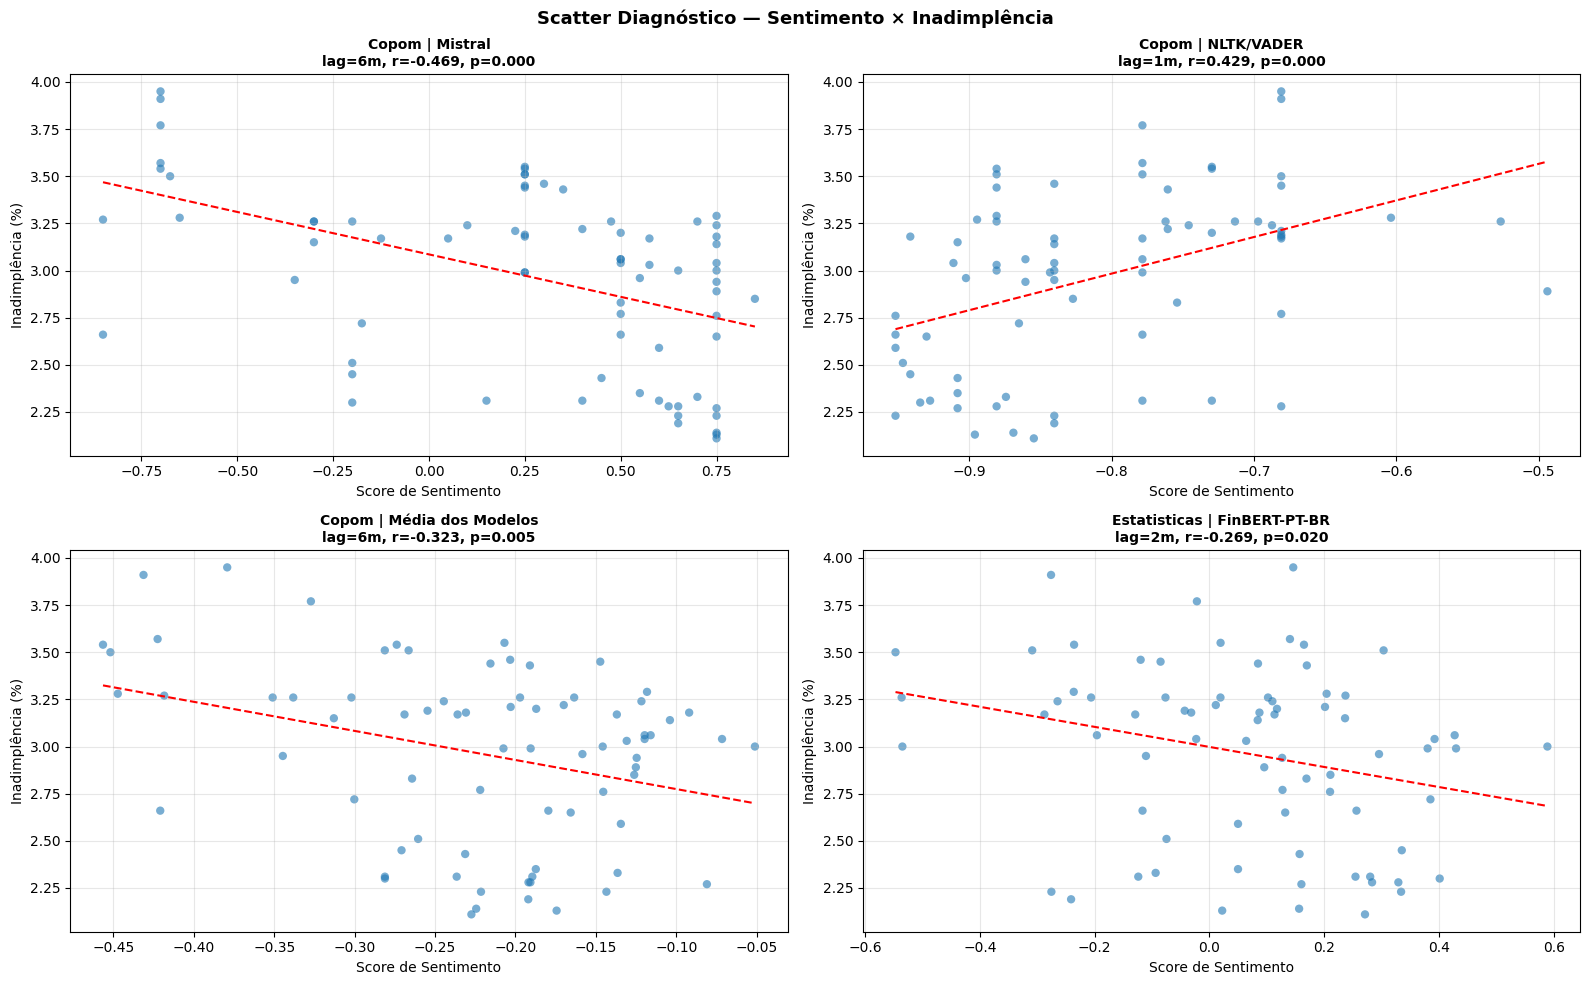

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top4_diagnostico.iterrows()):

    tipo_relatorio = row["Tipo Relatório"]
    col = row["col"]
    lag = int(row["Lag (meses)"])
    col_lag = f"{tipo_relatorio}_{col}_L{lag}"

    if col_lag not in df_export_final.columns:
        ax.set_title(f"{tipo_relatorio} | {nomes_display.get(col, col)}\nColuna não encontrada")
        ax.axis("off")
        continue

    df_tmp = (
        df_export_final[[COLUNA_INAD_CORRELACAO, col_lag]]
        .rename(columns={COLUNA_INAD_CORRELACAO: "inad", col_lag: "sent"})
        .dropna()
    )

    if len(df_tmp) < 5:
        ax.set_title(f"{tipo_relatorio} | {nomes_display.get(col, col)}\nDados insuficientes")
        ax.axis("off")
        continue

    r, p = stats.pearsonr(df_tmp["inad"], df_tmp["sent"])

    ax.scatter(
        df_tmp["sent"],
        df_tmp["inad"],
        alpha=0.6,
        edgecolors="none"
    )

    z = np.polyfit(df_tmp["sent"], df_tmp["inad"], 1)
    x_line = np.linspace(df_tmp["sent"].min(), df_tmp["sent"].max(), 100)

    ax.plot(
        x_line,
        np.poly1d(z)(x_line),
        "r--",
        linewidth=1.5
    )

    ax.set_title(
        f"{tipo_relatorio.capitalize()} | {nomes_display.get(col, col)}\n"
        f"lag={lag}m, r={r:.3f}, p={p:.3f}",
        fontweight="bold",
        fontsize=10
    )

    ax.set_xlabel("Score de Sentimento")
    ax.set_ylabel("Inadimplência (%)")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Scatter Diagnóstico — Sentimento × Inadimplência",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
